In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')
display(df.head())

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [16]:
numeric_columns = df.select_dtypes(include=np.number).columns

outlier_summery = []
for col in numeric_columns:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  outlier_summery.append({
      "column": col,
      "count": len(outliers),
      "lower_bound": lower_bound,
      "upper_bound": upper_bound,
      "outliers_Percentage": round(len(outliers)/len(df)*100,2)
  })
outlier_summery = pd.DataFrame(outlier_summery).sort_values(by="count",ascending=False)
outlier_summery

,column,count,lower_bound,upper_bound,outliers_Percentage
18,Profit_INR,404,-696111.000000,7.635670e+05,10.10
14,Production_Tonnes,333,-23.982500,5.335750e+01,8.33
20,Water_Efficiency_t_per_1000m3,322,-3.572875,1.038412e+01,8.05
13,Yield_Tonnes_Ha,302,-1.635000,5.525000e+00,7.55
19,Water_Used_m3,276,-6072.750000,1.617125e+04,6.90
17,Revenue_INR,240,-736519.000000,1.780911e+06,6.00
9,Potassium_kg_ha,32,30.100000,1.797000e+02,0.80
4,Sunlight_Hours_Day,26,4.350000,1.035000e+01,0.65
8,Phosphorus_kg_ha,16,11.400000,1.042000e+02,0.40
10,Fertilizer_kg_ha,15,19.137500,3.520375e+02,0.38


In [19]:
numeric_columns = df.select_dtypes(include=np.number).columns

outlier_summery = []
for col in numeric_columns:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  outlier_summery.append({
      "column": col,
      "count": len(outliers),
      "lower_bound": lower_bound,
      "upper_bound": upper_bound,
      "outliers_Percentage": round(len(outliers)/len(df)*100,2)
  })
outlier_summery = pd.DataFrame(outlier_summery).sort_values(by="count",ascending=False)
outlier_summery

,column,count,lower_bound,upper_bound,outliers_Percentage
18,Profit_INR,404,-696111.000000,7.635670e+05,10.10
14,Production_Tonnes,333,-23.982500,5.335750e+01,8.33
20,Water_Efficiency_t_per_1000m3,322,-3.572875,1.038412e+01,8.05
13,Yield_Tonnes_Ha,302,-1.635000,5.525000e+00,7.55
19,Water_Used_m3,276,-6072.750000,1.617125e+04,6.90
17,Revenue_INR,240,-736519.000000,1.780911e+06,6.00
9,Potassium_kg_ha,32,30.100000,1.797000e+02,0.80
4,Sunlight_Hours_Day,26,4.350000,1.035000e+01,0.65
8,Phosphorus_kg_ha,16,11.400000,1.042000e+02,0.40
10,Fertilizer_kg_ha,15,19.137500,3.520375e+02,0.38


In [20]:
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')
display(df.head())

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [21]:
df.tail(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [22]:
df.sample(5,random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.8,25.3,47.7,7.6,...,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.545,34.4
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.9,27.2,60.2,8.3,...,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.009,31.8
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,1213.7,26.3,73.6,7.1,...,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.654,52.7
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.0,17.9,59.7,9.4,...,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.293,29.8
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.8,19.0,55.8,9.2,...,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.363,39.6


In [23]:
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [25]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [26]:
df.describe(include='object')

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


In [27]:
from pandas._libs import missing
missing=df.isnull().sum().sort_values(ascending=False)
missing_percent=(df.isnull().mean()*100).sort_values(ascending=False)
missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percent': missing_percent.round(2)
})
missing_summary[missing_summary['Missing Count']>0]


,Missing Count,Missing Percent
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


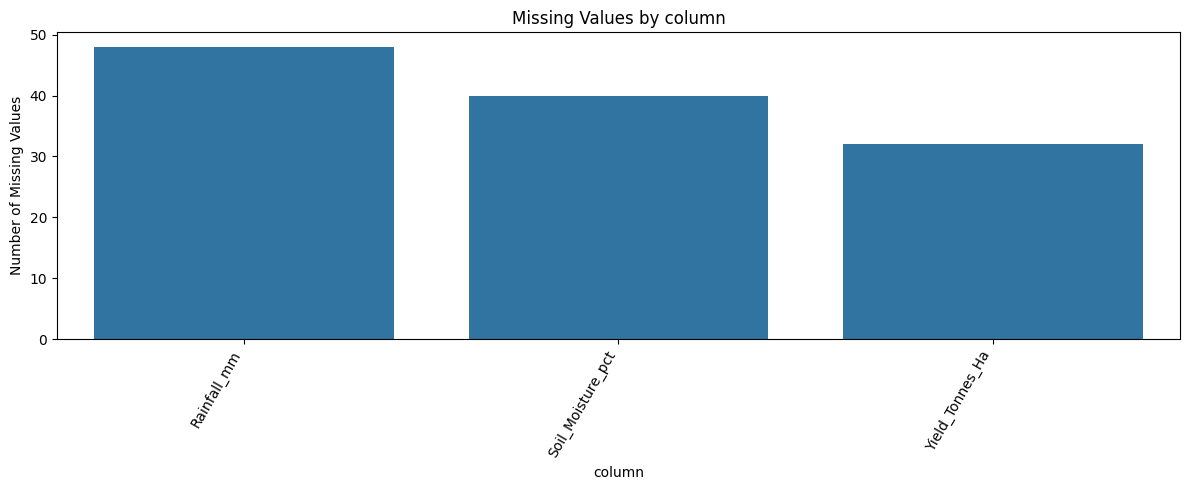

In [28]:
plt.figure(figsize=(12,5))
missing_plot = missing[missing>0]
if len(missing_plot)>0:
  sns.barplot(x=missing_plot.index,y=missing_plot.values)
  plt.xticks(rotation=60, ha="right")
  plt.ylabel("Number of Missing Values")
  plt.xlabel("column")
  plt.title("Missing Values by column")
  plt.tight_layout()
  plt.show()
else:
  print("No missing values")


In [29]:
duplicate_count = df.duplicated().sum()
print("number of duplicate rows:",duplicate_count)


number of duplicate rows: 0


In [30]:
df = df.drop_duplicates().reset_index(drop=True)
print("shape after removing duplicate: ",df.shape)

shape after removing duplicate:  (4000, 28)


In [31]:
df.datatypes = df.dtypes
print(df.datatypes)

Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Profit_INR      

/tmp/ipykernel_957/3067965415.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.datatypes = df.dtypes


In [32]:
from pandas.core.arrays import categorical
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
  print(f"\n{col}:")
  print(df[col].nunique(),"unique value")
  print(df[col].dropna().unique()[:20])



Farm_ID:
4000 unique value
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State:
8 unique value
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
10 unique value
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
8 unique value
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
3 unique value
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
4 unique value
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [33]:
df.isnull().sum().sort_values(ascending=False).head(10)

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32
Farm_ID,0
Crop,0
District,0
Farm_Area_Hectares,0
Season,0
Avg_Temperature_C,0
Humidity_pct,0


In [34]:
numeric_columns = df.select_dtypes(include=np.number).columns
for col in numeric_columns:
  if df[col].isnull().sum()>0:
    df[col]= df[col].fillna(df[col].median())
print("remaining values:",df.isnull().sum().sum())

remaining values: 0


In [35]:
stats = df[numeric_columns].describe().T
stats["range"] = stats["max"] - stats["min"]
stats['IQR'] = stats['75%'] - stats['25%']
stats

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00,14.500,7.39000
Rainfall_mm,4000.0,600.922825,287.193381,80.000,371.575,582.0000,831.97500,1395.20,1315.200,460.40000
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70,23.500,5.70000
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00,70.000,17.12500
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00,7.500,1.50000
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40,3.200,0.88000
Soil_Moisture_pct,4000.0,26.507150,6.678837,8.000,21.800,26.4000,31.20000,47.00,39.000,9.40000
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00,180.000,42.72500
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00,105.000,23.20000
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00,170.000,37.40000


In [36]:
statistical_summery = pd.DataFrame({
    "min": stats["min"],
    "max": stats["max"],
    "mean": stats["mean"],
    "median": stats["50%"],
    "std": stats["std"],
})
statistical_summery

,min,max,mean,median,std
Farm_Area_Hectares,0.500,15.00,7.888265,7.8950,4.223764
Rainfall_mm,80.000,1395.20,600.922825,582.0000,287.193381
Avg_Temperature_C,16.200,39.70,26.818900,26.9000,3.818180
Humidity_pct,25.000,95.00,63.210500,63.0000,11.960834
Sunlight_Hours_Day,3.500,11.00,7.323050,7.3000,1.121186
Soil_pH,5.200,8.40,6.701010,6.6900,0.641461
Soil_Moisture_pct,8.000,47.00,26.507150,26.4000,6.678837
Nitrogen_kg_ha,40.000,220.00,120.250825,120.1000,31.216452
Phosphorus_kg_ha,15.000,120.00,57.781850,57.5000,17.015074
Potassium_kg_ha,30.000,200.00,104.760050,105.1000,27.742681


In [37]:
season_summery = df.groupby("Season")[numeric_columns].agg(["mean","median","std"])
season_summery

Farm_Area_Hectares                  Rainfall_mm                     \
                     mean median       std        mean median         std   
Season                                                                      
Kharif           7.944924  8.180  4.282328  849.199663  853.1  183.686045   
Rabi             7.752207  7.680  4.179402  437.615366  432.2  175.351345   
Zaid             8.091246  8.085  4.162594  304.654714  288.2  157.238490   

       Avg_Temperature_C                  Humidity_pct  ...     Profit_INR  \
                    mean median       std         mean  ...            std   
Season                                                  ...                  
Kharif         28.454019   28.5  2.510166    71.812591  ...  611549.783883   
Rabi           23.489183   23.5  2.459561    57.893178  ...  489901.254255   
Zaid           31.042088   31.0  2.554911    52.012121  ...  436356.747261   

       Water_Used_m3                      Water_Efficiency_t_per_1000m3  \
                mean  median          std                          mean   
Season                                                                    
Kharif   6102.201237  4469.0  5670.582696                      5.891834   
Rabi     5846.987093  4292.0  5397.648066                      5.186122   
Zaid     6419.893939  4805.0  5734.619854                      4.413239   

                         Disease_Pest_Risk_pct                    
        median       std                  mean median        std  
Season                                                            
Kharif  3.2770  9.833333             54.467903   54.5  10.087931  
Rabi    2.7400  8.258037             40.482114   40.6  10.104157  
Zaid    2.3015  6.930111             38.216667   37.9   9.873938  

[3 rows x 66 columns]

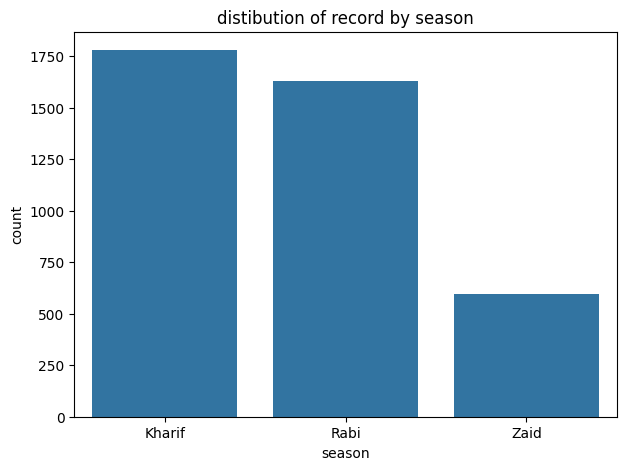

In [38]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,x="Season")
plt.title("distibution of record by season")
plt.xlabel("season")
plt.ylabel("count")
plt.show()

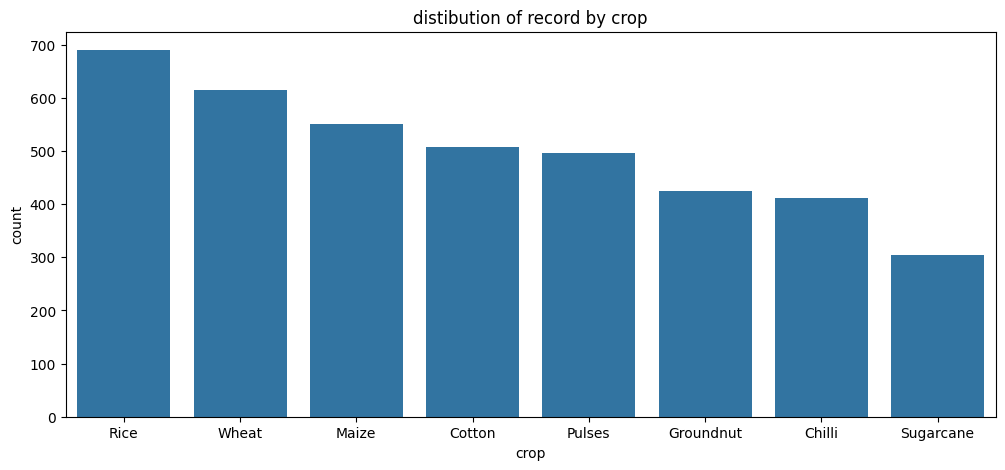

In [39]:
plt.figure(figsize=(12,5))
sns.countplot(data=df,x="Crop",order=df["Crop"].value_counts().index)
plt.title("distibution of record by crop")
plt.xlabel("crop")
plt.ylabel("count")
plt.show()

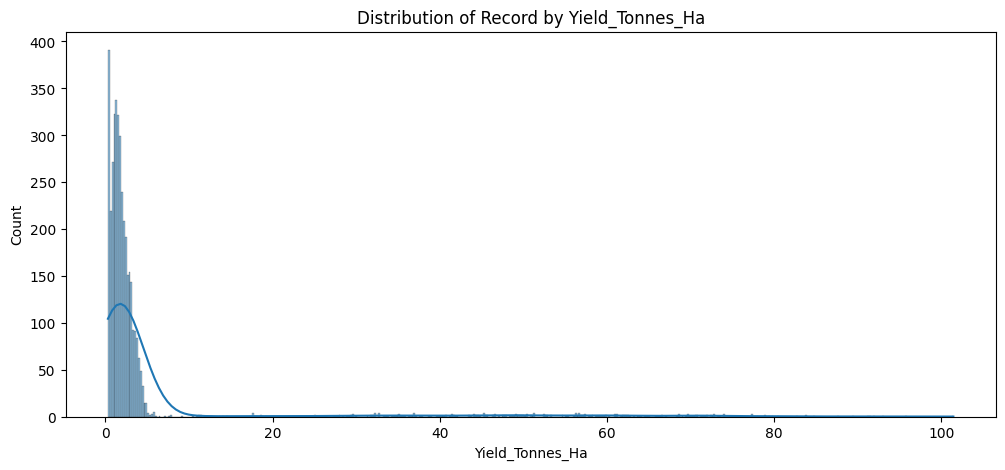

In [40]:
plt.figure(figsize=(12,5))
sns.histplot(data=df,x="Yield_Tonnes_Ha",kde=True)
plt.title("Distribution of Record by Yield_Tonnes_Ha")
plt.xlabel("Yield_Tonnes_Ha")
plt.ylabel("Count")
plt.show()

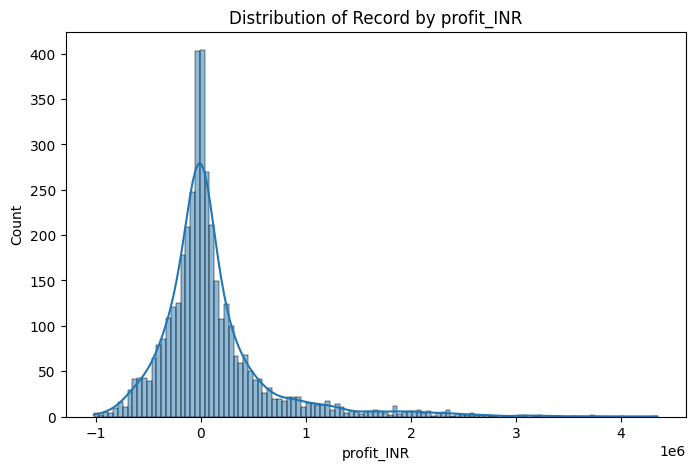

In [41]:
plt.figure(figsize=(8,5))
sns.histplot(data=df,x="Profit_INR",kde=True)
plt.title("Distribution of Record by profit_INR")
plt.xlabel("profit_INR")
plt.ylabel("Count")
plt.show()

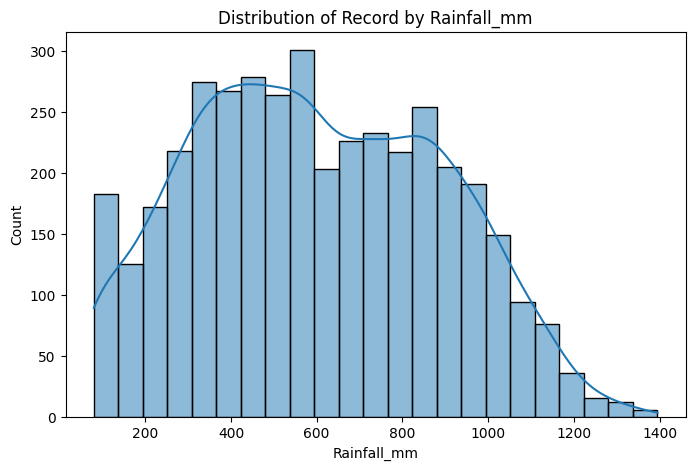

In [42]:
plt.figure(figsize=(8,5))
sns.histplot(data=df,x="Rainfall_mm",kde=True)
plt.title("Distribution of Record by Rainfall_mm")
plt.xlabel("Rainfall_mm")
plt.ylabel("Count")
plt.show()

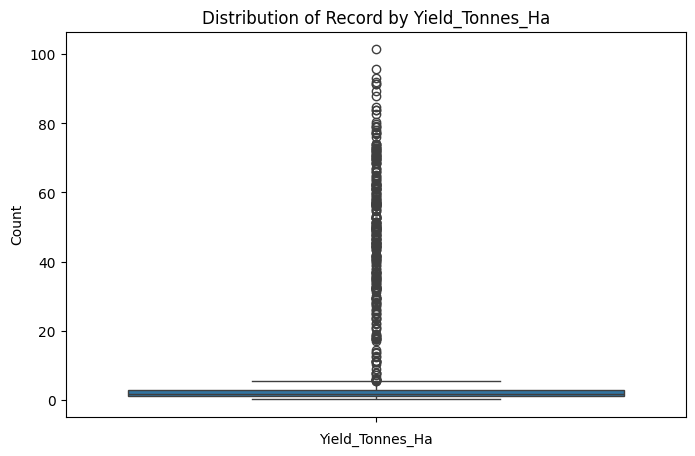

In [43]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,y="Yield_Tonnes_Ha")
plt.title("Distribution of Record by Yield_Tonnes_Ha")
plt.xlabel("Yield_Tonnes_Ha")
plt.ylabel("Count")
plt.show()

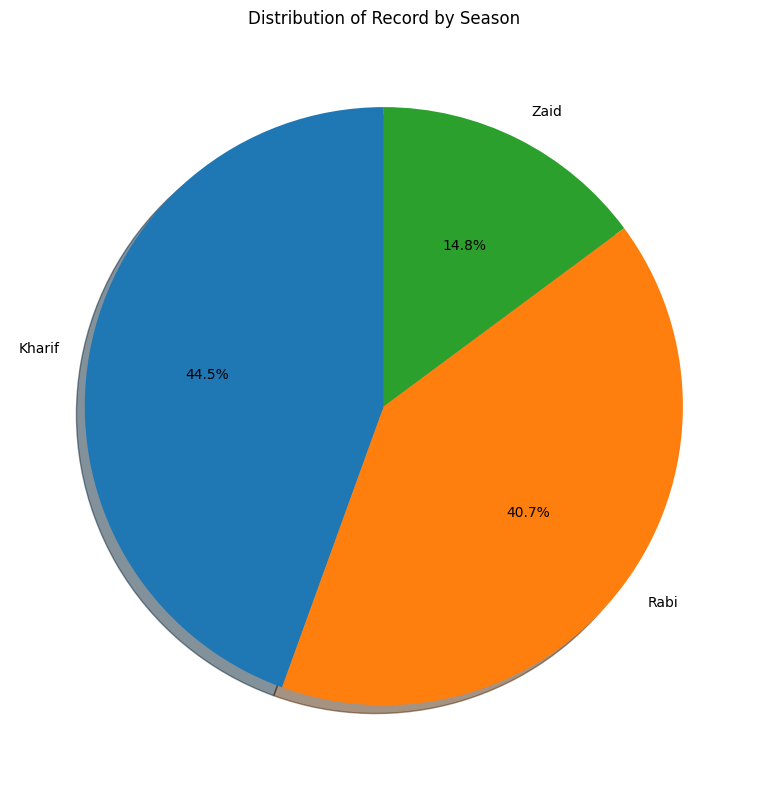

In [44]:
plt.figure(figsize=(8,8))
df['Season'].value_counts().plot.pie(autopct='%1.1f%%',startangle=90,shadow=True)
plt.title("Distribution of Record by Season")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [45]:
numeric_columns = df.select_dtypes(include=np.number).columns

outlier_summery = []
for col in numeric_columns:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  outlier_summery.append({
      "column": col,
      "count": len(outliers),
      "lower_bound": lower_bound,
      "upper_bound": upper_bound,
      "outliers_Percentage": round(len(outliers)/len(df)*100,2)
  })
outlier_summery = pd.DataFrame(outlier_summery).sort_values(by="count",ascending=False)
outlier_summery

,column,count,lower_bound,upper_bound,outliers_Percentage
18,Profit_INR,404,-696111.000000,7.635670e+05,10.10
14,Production_Tonnes,333,-23.982500,5.335750e+01,8.33
20,Water_Efficiency_t_per_1000m3,322,-3.572875,1.038412e+01,8.05
13,Yield_Tonnes_Ha,302,-1.620000,5.500000e+00,7.55
19,Water_Used_m3,276,-6072.750000,1.617125e+04,6.90
17,Revenue_INR,240,-736519.000000,1.780911e+06,6.00
9,Potassium_kg_ha,32,30.100000,1.797000e+02,0.80
4,Sunlight_Hours_Day,26,4.350000,1.035000e+01,0.65
8,Phosphorus_kg_ha,16,11.400000,1.042000e+02,0.40
10,Fertilizer_kg_ha,15,19.137500,3.520375e+02,0.38


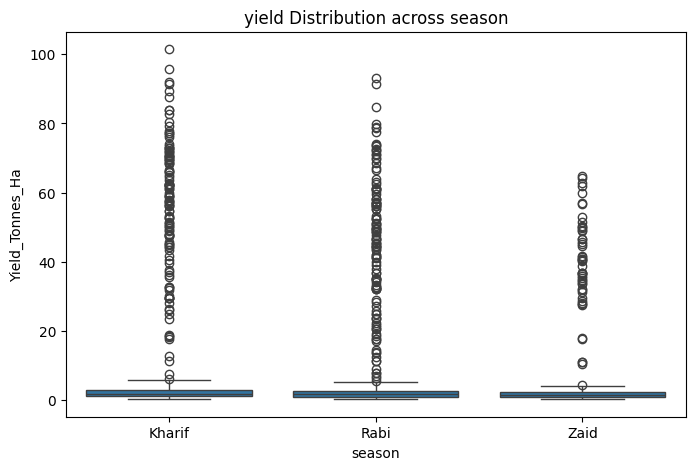

In [47]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Season",y="Yield_Tonnes_Ha")
plt.title("yield Distribution across season")
plt.xlabel("season")
plt.ylabel("Yield_Tonnes_Ha")
plt.show()

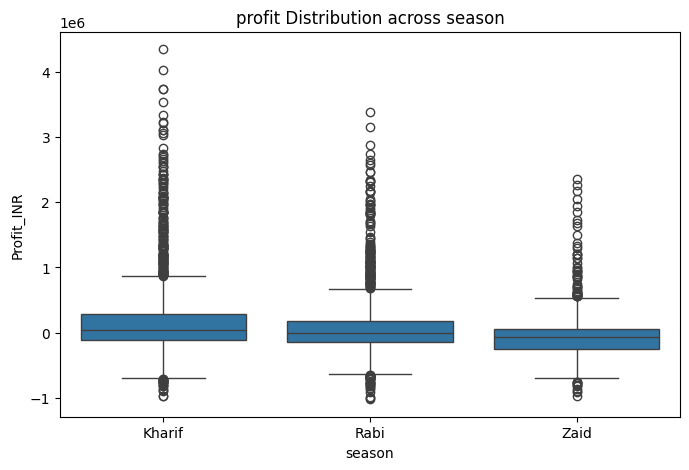

In [48]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Season",y="Profit_INR")
plt.title("profit Distribution across season")
plt.xlabel("season")
plt.ylabel("Profit_INR")
plt.show()

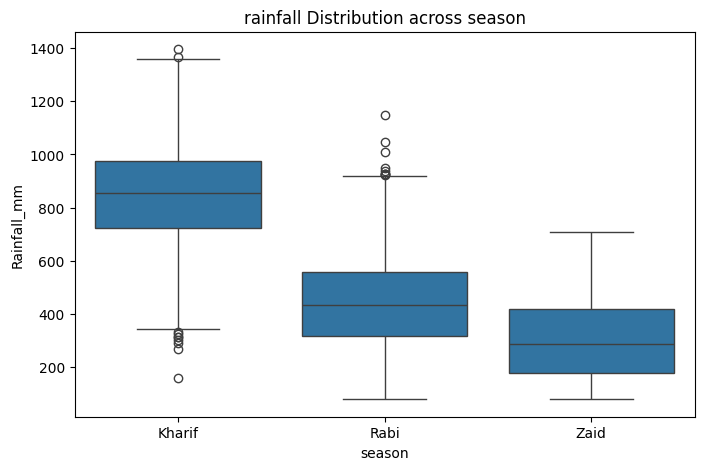

In [49]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Season",y="Rainfall_mm")
plt.title("rainfall Distribution across season")
plt.xlabel("season")
plt.ylabel("Rainfall_mm")
plt.show()

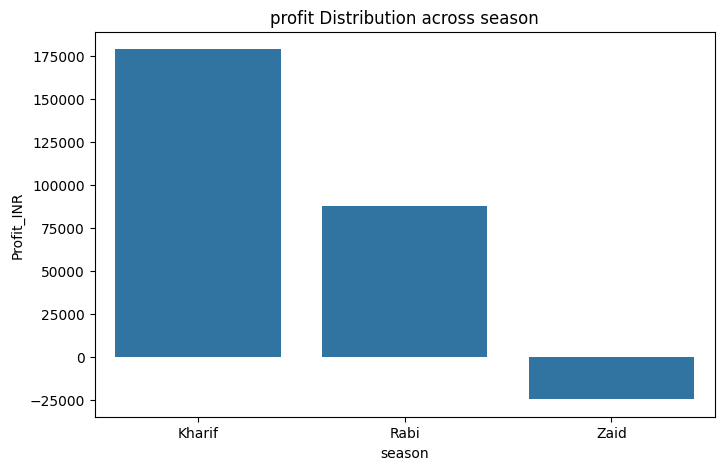

In [50]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="Season",y="Profit_INR",errorbar=None)
plt.title("profit Distribution across season")
plt.xlabel("season")
plt.ylabel("Profit_INR")
plt.show()


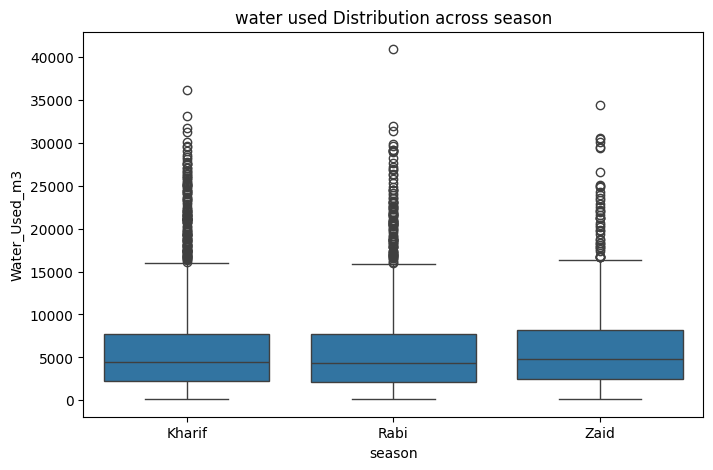

In [51]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Season",y="Water_Used_m3")
plt.title("water used Distribution across season")
plt.xlabel("season")
plt.ylabel("Water_Used_m3")
plt.show()

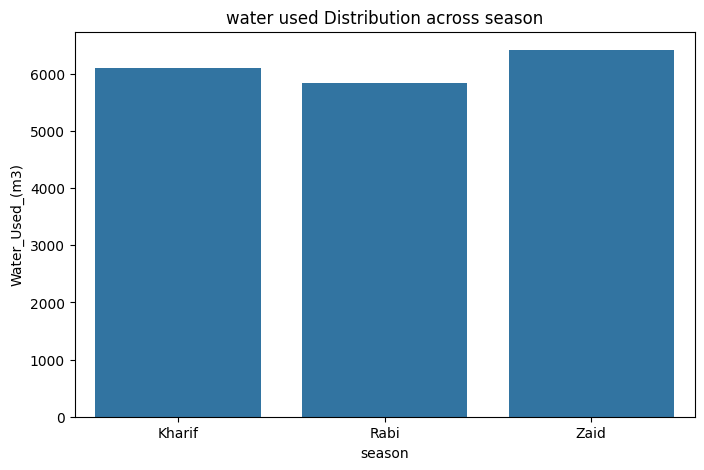

In [53]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="Season",y="Water_Used_m3",errorbar=None)
plt.title("water used Distribution across season")
plt.xlabel("season")
plt.ylabel("Water_Used_(m3)")
plt.show()

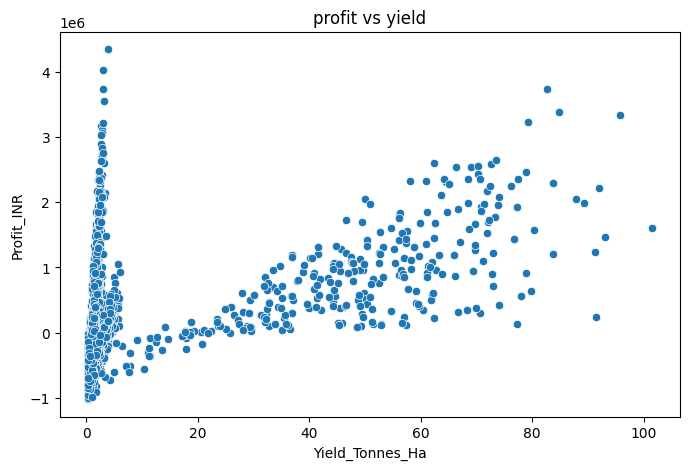

In [54]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="Yield_Tonnes_Ha",y="Profit_INR")
plt.title("profit vs yield")
plt.xlabel("Yield_Tonnes_Ha")
plt.ylabel("Profit_INR")
plt.show()

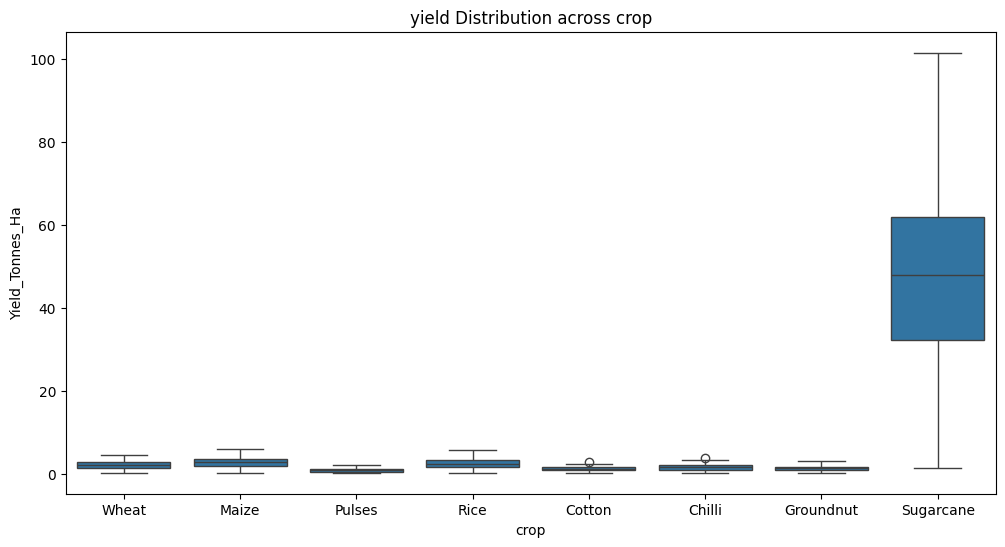

In [56]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df,x="Crop",y="Yield_Tonnes_Ha")
plt.title("yield Distribution across crop")
plt.xlabel("crop")
plt.ylabel("Yield_Tonnes_Ha")
plt.show()


<Figure size 1200x600 with 0 Axes>

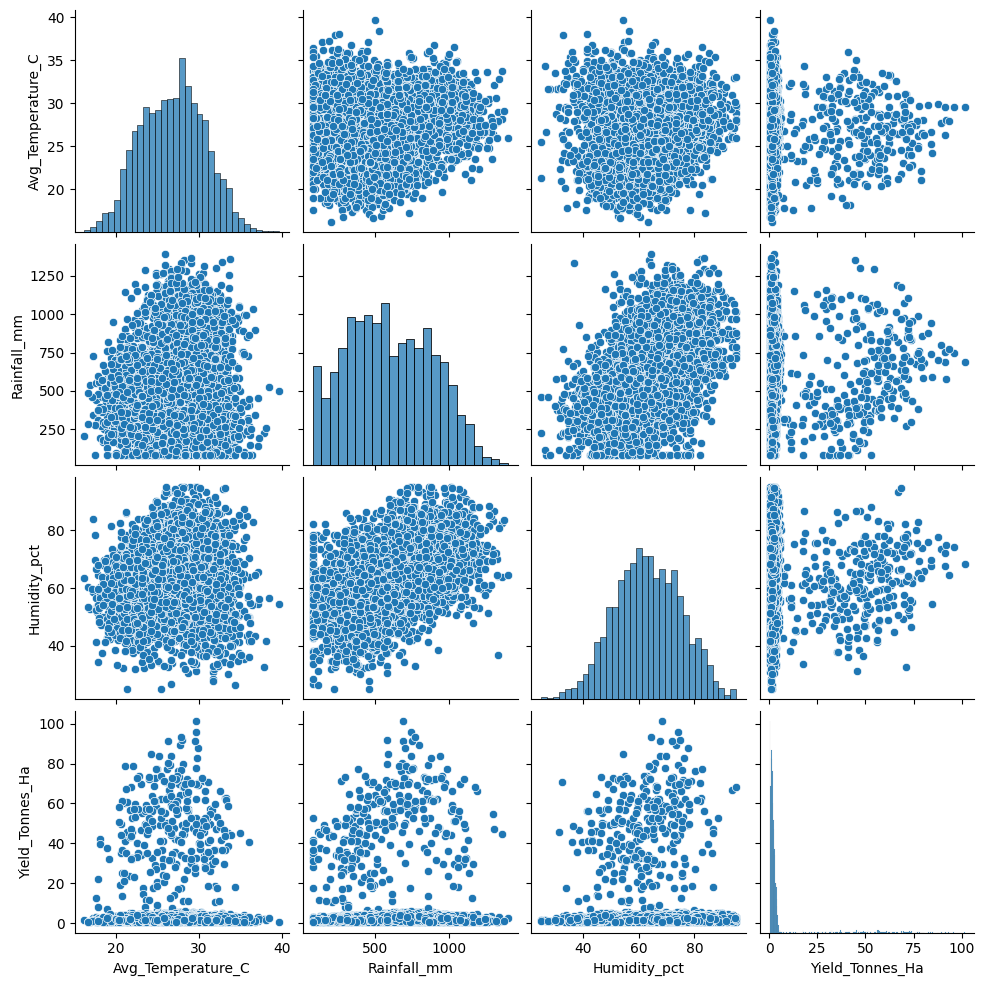

In [57]:
selected_columns = ["Avg_Temperature_C",'Rainfall_mm','Humidity_pct','Yield_Tonnes_Ha']
plt.figure(figsize=(12,6))
sns.pairplot(df[selected_columns])
plt.show()

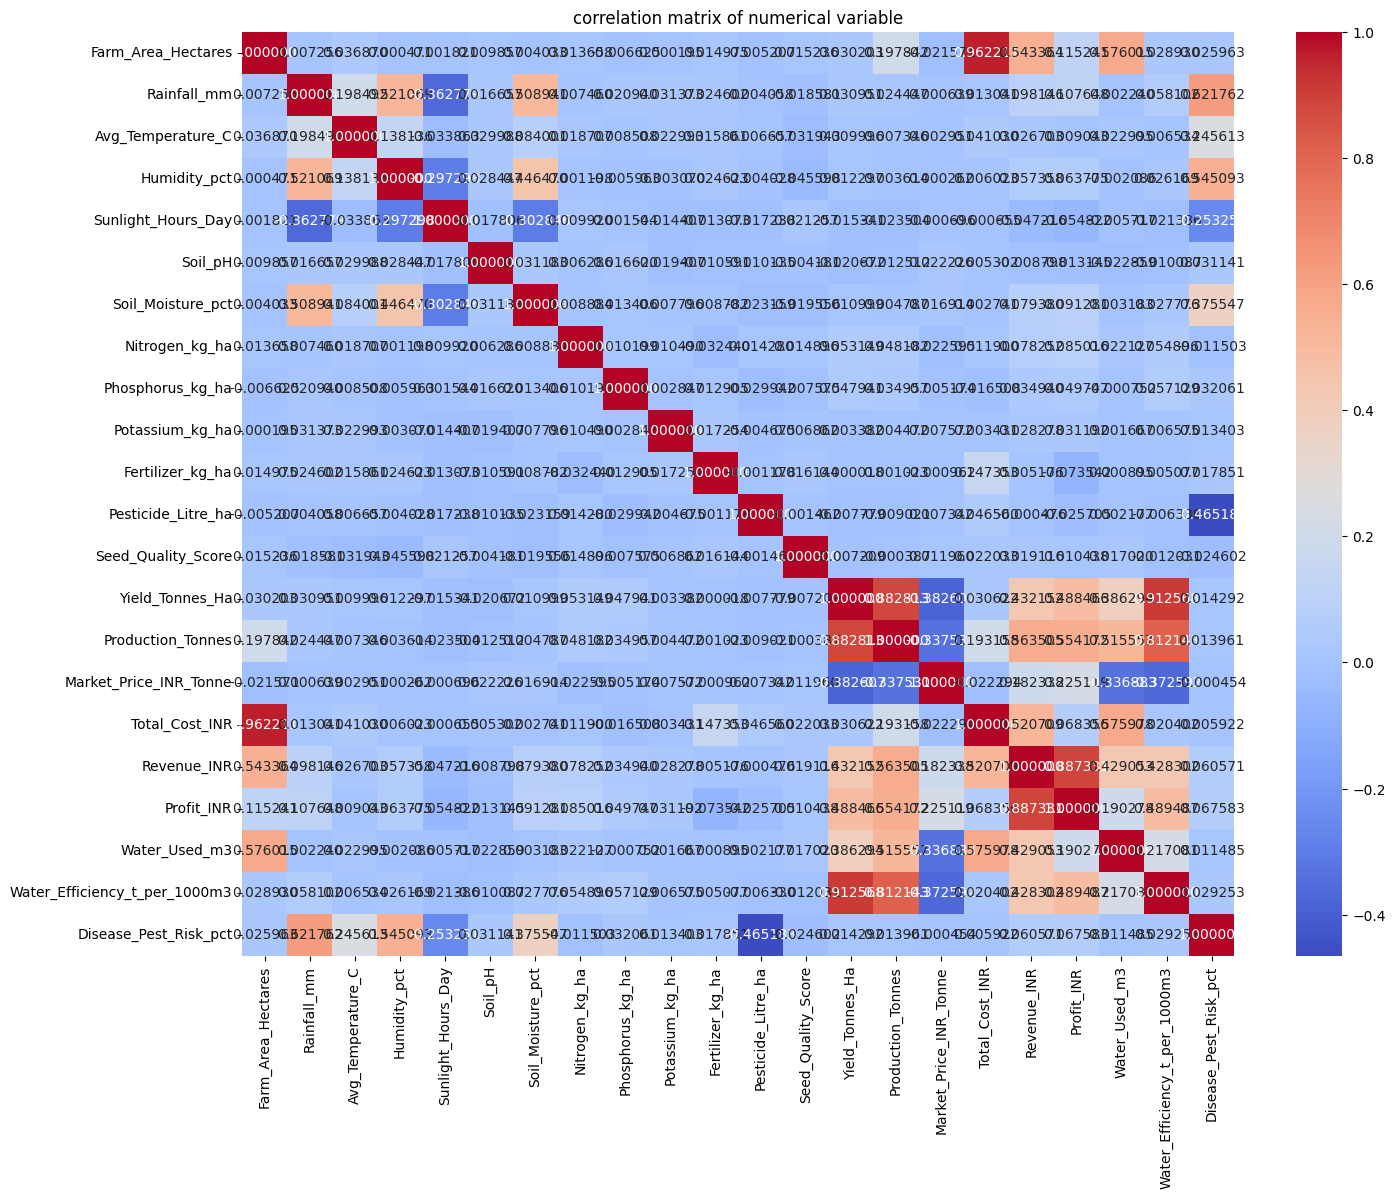

In [58]:
plt.figure(figsize=(16,12))
corr = df[numeric_columns].corr(numeric_only=True)
sns.heatmap(corr,annot=True,fmt="2f",cmap="coolwarm")
plt.title("correlation matrix of numerical variable")
plt.show()

In [63]:
crop_season_summery =( df.groupby(["Crop","Season"]).agg(
    Average_Yield=("Yield_Tonnes_Ha","mean"),
    Average_Profit=("Profit_INR","mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3","mean")
)
.round(2)
.sort_values(["Season","Average_Yield"],ascending=[True,False])
)
crop_season_summery

,,Average_Yield,Average_Profit,Average_Water_Efficiency
Crop,Season,,,
Sugarcane,Kharif,53.46,1000790.81,36.00
Maize,Kharif,2.97,-39332.67,6.05
Rice,Kharif,2.70,-64903.40,2.17
Wheat,Kharif,2.25,-105871.87,4.76
Chilli,Kharif,1.73,954380.42,3.26
Groundnut,Kharif,1.48,108265.44,3.58
Cotton,Kharif,1.37,216999.55,2.13
Pulses,Kharif,1.04,43338.90,3.35
Sugarcane,Rabi,43.29,731612.86,27.92
